<a href="https://colab.research.google.com/github/TranNguyenMinhQuan/BaiTapDuLieuSau/blob/main/Ontap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [2]:
np.random.seed(42)

ma_kh = [f"KH{str(i).zfill(3)}" for i in range(1, 501)]

tuoi = np.random.randint(18, 71, size=500).astype(float)
nan_tuoi_idx = np.random.choice(500, size=10, replace=False)
tuoi[nan_tuoi_idx] = np.nan

thu_nhap = np.random.uniform(5000000, 50000000, size=500)
outliers_idx = np.random.choice(500, size=5, replace=False)
thu_nhap[outliers_idx] = np.random.uniform(150000000, 20000000, size=5)

gioi_tinh = np.random.choice(['Nam', 'Nữ'], size=500).astype(object)
nan_gt_idx = np.random.choice(500, size=15, replace=False)
gioi_tinh[nan_gt_idx] = np.nan

thanh_pho = np.random.choice(['Hà Nội', 'Đà Nẵng', 'TP.HCM'], size=500)

tong_chi_tieu = thu_nhap * 0.3 + np.random.normal(0, 2000000, size=500)
tong_chi_tieu = np.clip(tong_chi_tieu, 1000000, None)

df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,1.986568e+07,NaN,Hà Nội,2.357589e+06
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,1.301949e+07
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,1.000000e+06
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,3.300298e+06
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,6.096029e+06


In [3]:
print(df_khachhang.isnull().sum())

tuoi_median = df_khachhang['Tuoi'].median()
df_khachhang['Tuoi'] = df_khachhang['Tuoi'].fillna(tuoi_median)

gioi_tinh_mode = df_khachhang['GioiTinh'].mode()[0]
df_khachhang['GioiTinh'] = df_khachhang['GioiTinh'].fillna(gioi_tinh_mode)

print(df_khachhang.isnull().sum())

MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


In [4]:
df_thanhpho_encoded = pd.get_dummies(df_khachhang['ThanhPho'], prefix='ThanhPho', dtype=int)
df_khachhang = pd.concat([df_khachhang, df_thanhpho_encoded], axis=1)

df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng
0,KH001,56.0,1.986568e+07,Nữ,Hà Nội,2.357589e+06,1,0,0
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,1.301949e+07,0,1,0
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,1.000000e+06,1,0,0
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,3.300298e+06,0,1,0
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,6.096029e+06,1,0,0


In [5]:
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_khachhang = df_khachhang[(df_khachhang['ThuNhap'] >= lower_bound) & (df_khachhang['ThuNhap'] <= upper_bound)]

df_khachhang.shape

(499, 9)

In [6]:
scaler = MinMaxScaler()
df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(df_khachhang[['TongChiTieu']])

df_khachhang[['TongChiTieu', 'TongChiTieu_Scaled']].head()

,TongChiTieu,TongChiTieu_Scaled
0,2.357589e+06,0.070306
1,1.301949e+07,0.622456
2,1.000000e+06,0.000000
3,3.300298e+06,0.119126
4,6.096029e+06,0.263909


In [7]:
df_filtered = df_khachhang[(df_khachhang['GioiTinh'] == 'Nữ') & (df_khachhang['Tuoi'] > 30) & (df_khachhang['ThanhPho'] == 'Hà Nội')]

df_filtered.head(5)

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
0,KH001,56.0,1.986568e+07,Nữ,Hà Nội,2.357589e+06,1,0,0,0.070306
16,KH017,41.0,3.091993e+07,Nữ,Hà Nội,6.816879e+06,1,0,0,0.301240
18,KH019,39.0,5.238500e+06,Nữ,Hà Nội,1.000000e+06,1,0,0,0.000000
19,KH020,70.0,4.887802e+07,Nữ,Hà Nội,1.445151e+07,1,0,0,0.696616
21,KH022,41.0,3.753032e+07,Nữ,Hà Nội,8.253157e+06,1,0,0,0.375620


In [8]:
grouped_stats = df_khachhang.groupby('ThanhPho')['TongChiTieu'].agg(['mean', 'sum'])

print(grouped_stats)

                  mean           sum
ThanhPho                            
Hà Nội    8.414798e+06  1.539908e+09
TP.HCM    8.910396e+06  1.479126e+09
Đà Nẵng   8.354238e+06  1.253136e+09


In [9]:
bins = [17, 30, 45, 60, np.inf]
labels = ['18-30', '31-45', '46-60', 'Trên 60']

df_khachhang['NhomTuoi'] = pd.cut(df_khachhang['Tuoi'], bins=bins, labels=labels)

df_khachhang[['Tuoi', 'NhomTuoi']].head()

,Tuoi,NhomTuoi
0,56.0,46-60
1,69.0,Trên 60
2,46.0,46-60
3,32.0,31-45
4,60.0,46-60


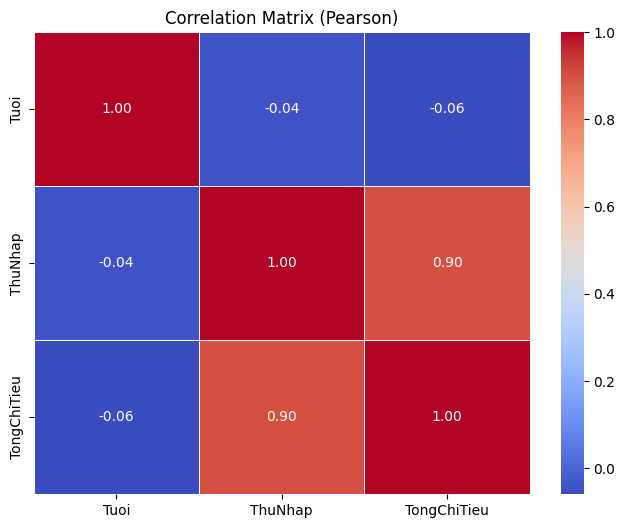

In [10]:
numeric_cols = df_khachhang[['Tuoi', 'ThuNhap', 'TongChiTieu']]
corr_matrix = numeric_cols.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Pearson)')
plt.show()

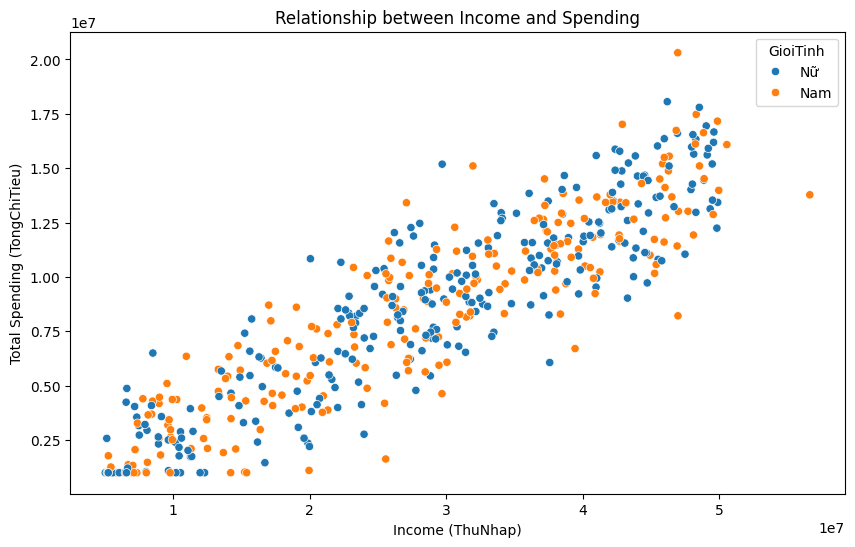

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_khachhang, x='ThuNhap', y='TongChiTieu', hue='GioiTinh')
plt.title('Relationship between Income and Spending')
plt.xlabel('Income (ThuNhap)')
plt.ylabel('Total Spending (TongChiTieu)')
plt.show()

In [13]:
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.8403 - loss: 0.4519 - val_accuracy: 0.8768 - val_loss: 0.3468
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.8941 - loss: 0.3001 - val_accuracy: 0.8927 - val_loss: 0.3079
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9063 - loss: 0.2585 - val_accuracy: 0.9052 - val_loss: 0.2701
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9161 - loss: 0.2329 - val_accuracy: 0.9002 - val_loss: 0.2793
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9245 - loss: 0.2087 - val_accuracy: 0.9105 - val_loss: 0.2603
313/313 - 2s - 6ms/step - accuracy: 0.9060 - loss: 0.2683

Test Accuracy: 0.9060
